In [1]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings 
warnings.filterwarnings('ignore')

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix

from sklearn.metrics import ConfusionMatrixDisplay

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

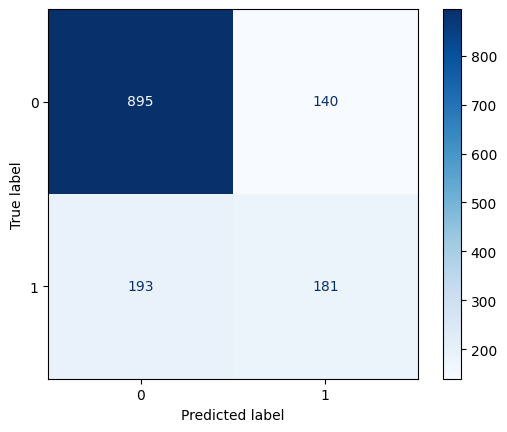

                            Feature  Importance
1               num__MonthlyCharges    0.480954
0                       num__tenure    0.287489
5      cat__Contract_Month-to-month    0.084685
3            cat__OnlineSecurity_No    0.047378
4               cat__TechSupport_No    0.042210
2  cat__InternetService_Fiber optic    0.040619
6            cat__Contract_Two year    0.016665


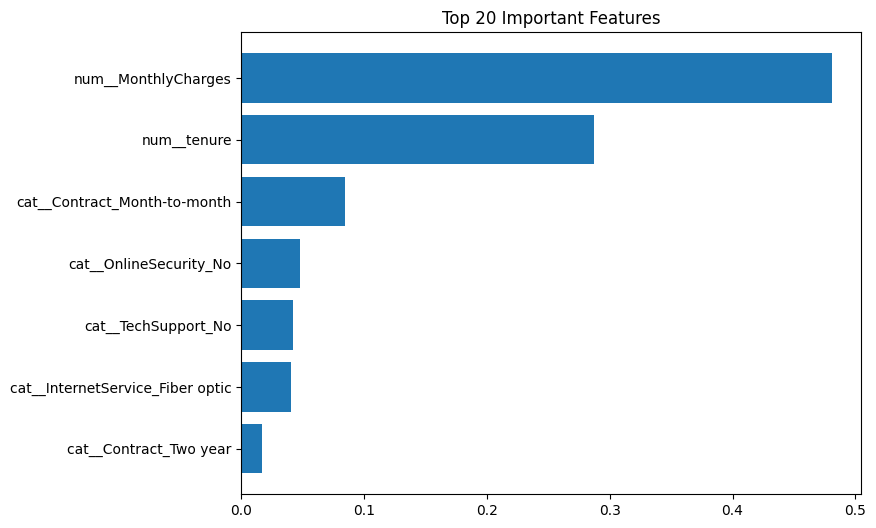

[0]


In [3]:
df_churn = pd.read_csv("Telco_Customer_Churn.csv")
#df_churn


print(df_churn.info())

print(df_churn.isnull().sum())

print(df_churn.duplicated().sum())

df_churn.skew(numeric_only=True)


df_churn.corr(numeric_only=True)

df_churn.drop('customerID', axis=1, inplace = True)


X = df_churn.drop('Churn', axis=1)
y = df_churn['Churn']

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_le = le.fit_transform(y)


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_le,
    test_size=0.2,
    random_state=42,
    stratify=y
)



num_features = X.select_dtypes(include=['int64', 'float64']).columns

cat_features = X.select_dtypes(include=['str']).columns



num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

num_pipe

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ])

cat_pipe

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipe, num_features),
        ('cat', cat_pipe, cat_features)
    ]
)

preprocessor

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif


feature_selector = SelectKBest(
    score_func=mutual_info_classif,
    k=7
)

feature_selector



model = Pipeline([
    ('preprocessor', preprocessor),
    ('feature_selection', feature_selector),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

model

model.fit(X_train,y_train) 

y_pred = model.predict(X_test)
y_pred

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

print(cm)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")

plt.show()


# Cross Validation Score

#from sklearn.model_selection import cross_val_score

#scores = cross_val_score(
#    model,
#    X,
#    y,
#    cv=5,
#    scoring="accuracy"
#)
#print(scores)

#print("Average Accuracy :", scores.mean())

feature_names = model.named_steps['preprocessor'].get_feature_names_out()
feature_names


importance = model.named_steps['classifier'].feature_importances_
importance


# All feature names after preprocessing
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

# SelectKBest object
selector = model.named_steps['feature_selection']

# Selected feature names
selected_feature_names = feature_names[selector.get_support()]


#print(selected_feature_names)
# Feature importances
importance = model.named_steps['classifier'].feature_importances_

# Create DataFrame
feature_importance = pd.DataFrame({
    "Feature": selected_feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)


feature_importance.head(10)


top20 = feature_importance.head(20)

plt.figure(figsize=(8,6))

plt.barh(top20["Feature"], top20["Importance"])

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features")

plt.show()


# Save the Model

import joblib

joblib.dump(model, "telco_customer_churn.pkl")


# Predict New Data

new_data = pd.DataFrame({
    "gender": ["Female"],
    "SeniorCitizen": [0],
    "Partner": ["Yes"],
    "Dependents": ["No"],
    "tenure": [24],
    "PhoneService": ["Yes"],
    "MultipleLines": ["No"],
    "InternetService": ["Fiber optic"],
    "OnlineSecurity": ["No"],
    "OnlineBackup": ["Yes"],
    "DeviceProtection": ["Yes"],
    "TechSupport": ["No"],
    "StreamingTV": ["Yes"],
    "StreamingMovies": ["Yes"],
    "Contract": ["Month-to-month"],
    "PaperlessBilling": ["Yes"],
    "PaymentMethod": ["Electronic check"],
    "MonthlyCharges": [79.85],
    "TotalCharges": [1850.55]
})

prediction = model.predict(new_data)

print(prediction)

